# NYC Yellow Taxi + Météo — Analyse complète
## Pipeline de données modulaire v2.0

Ce notebook répond à **9 questions analytiques** en 3 parties :
- **Partie 1** — Questions Spark (données taxi brutes)
- **Partie 2** — Questions Streaming (données météo)
- **Partie 3** — Questions dbt (modèles enrichis)

**Source des données :**
- Taxi : TLC Yellow Taxi Jan-Mars 2024 (8,441,641 trajets)
- Météo : OpenWeatherMap simulé Jan-Mars 2024 (2,184 observations)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import psycopg2
import warnings
warnings.filterwarnings('ignore')

# Style visuel
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

# Connexion PostgreSQL (port 5435 = port Docker exposé sur le 5432 interne)
conn = psycopg2.connect(
    host='localhost',
    port=5435,
    dbname='nyc_pipeline',
    user='pipeline',
    password='pipeline'
)

def query(sql):
    return pd.read_sql(sql, conn)

print('Connexion PostgreSQL établie')
print(f'   Hôte : localhost:5435 | Base : nyc_pipeline')

Connexion PostgreSQL établie
   Hôte : localhost:5435 | Base : nyc_pipeline


---
## Partie 1 — Questions Spark
### Q1 : Quelle est la distribution des durées de trajets ?

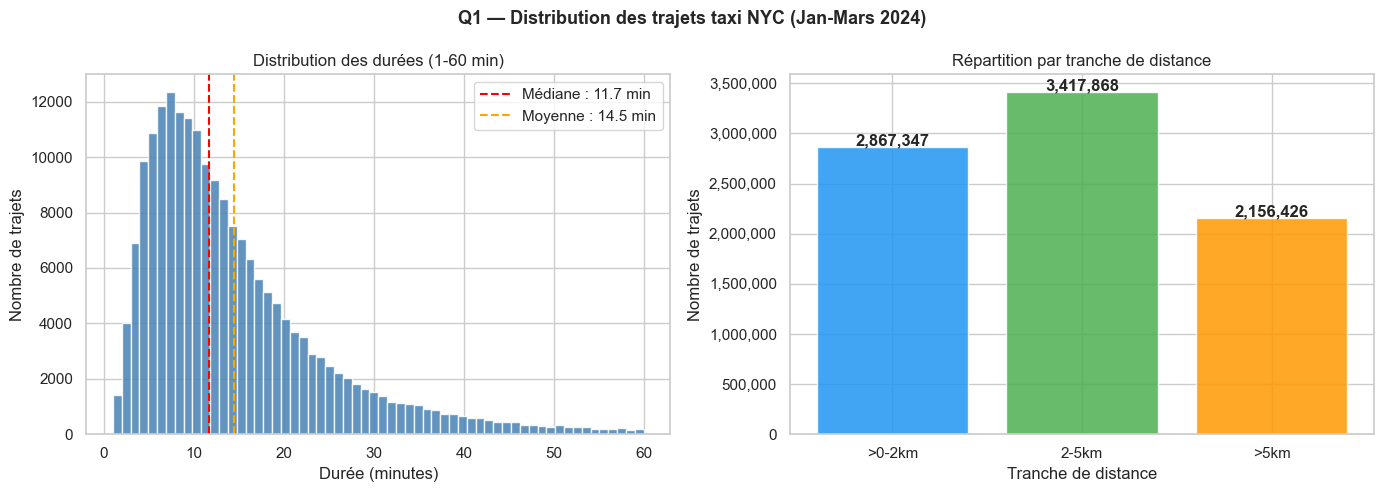

Résultats Q1 :
   Durée médiane  : 11.7 min
   Durée moyenne  : 14.5 min
   75% des trajets durent moins de : 18.6 min

   Distribution par distance :
   >0-2km   : 2,867,347 trajets
   2-5km    : 3,417,868 trajets
   >5km     : 2,156,426 trajets


In [2]:
# Q1 : échantillon 200k trajets (charger les 8.4M en mémoire serait inutile pour un graphique)

df_dur = query("""
    SELECT trip_duration_minutes
    FROM raw.fact_taxi_trips
    WHERE trip_duration_minutes BETWEEN 1 AND 60
    LIMIT 200000
""")

df_bkt = query("""
    SELECT distance_bucket,
           COUNT(*) as nb_trajets
    FROM raw.fact_taxi_trips
    GROUP BY distance_bucket
    ORDER BY distance_bucket
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q1 — Distribution des trajets taxi NYC (Jan-Mars 2024)',
             fontweight='bold', fontsize=13)

mediane = df_dur['trip_duration_minutes'].median()
moyenne = df_dur['trip_duration_minutes'].mean()

axes[0].hist(df_dur['trip_duration_minutes'], bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mediane, color='red', linestyle='--', linewidth=1.5,
                label=f'Médiane : {mediane:.1f} min')
axes[0].axvline(moyenne, color='orange', linestyle='--', linewidth=1.5,
                label=f'Moyenne : {moyenne:.1f} min')
axes[0].set_title('Distribution des durées (1-60 min)')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('Nombre de trajets')
axes[0].legend()

bars = axes[1].bar(df_bkt['distance_bucket'], df_bkt['nb_trajets'],
                   color=COLORS[:3], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, df_bkt['nb_trajets']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15000,
                 f'{val:,.0f}', ha='center', fontweight='bold')
axes[1].set_title('Répartition par tranche de distance')
axes[1].set_xlabel('Tranche de distance')
axes[1].set_ylabel('Nombre de trajets')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('q1_distribution_durees.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Résultats Q1 :")
print(f"   Durée médiane  : {mediane:.1f} min")
print(f"   Durée moyenne  : {moyenne:.1f} min")
print(f"   75% des trajets durent moins de : {df_dur['trip_duration_minutes'].quantile(0.75):.1f} min")
print(f"\n   Distribution par distance :")
for _, r in df_bkt.iterrows():
    print(f"   {r['distance_bucket']:8s} : {r['nb_trajets']:>9,.0f} trajets")

### Q2 : Les longs trajets reçoivent-ils plus de pourboires ?

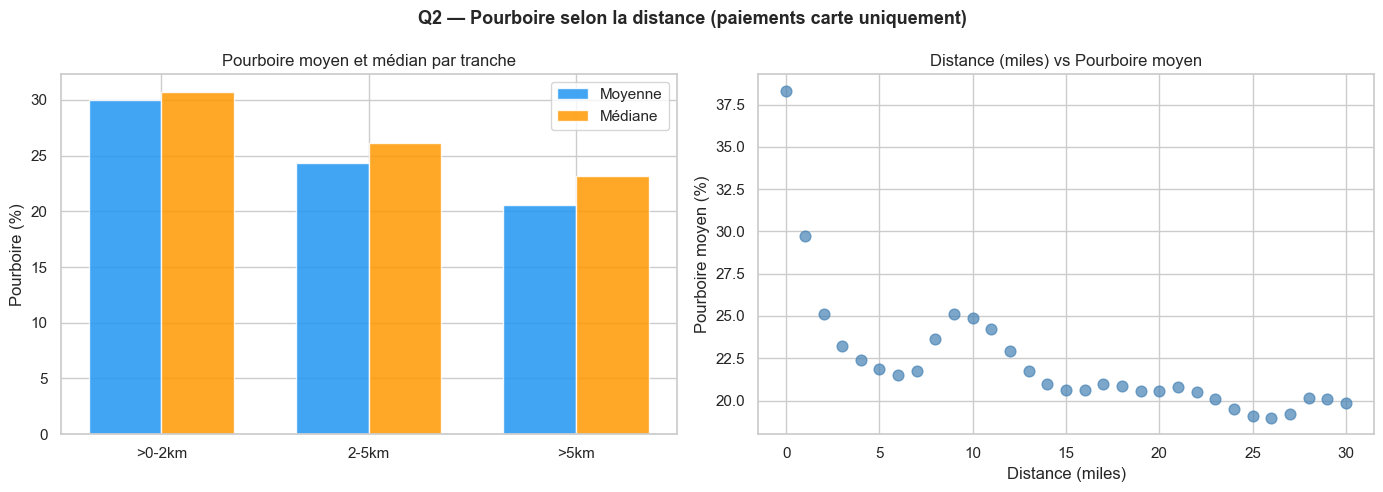

Résultats Q2 :
distance_bucket  avg_tip_pct  median_tip_pct  nb_trajets
         >0-2km        30.03           30.75     2356159
          2-5km        24.32           26.13     2924430
           >5km        20.57           23.13     1815354

   Corrélation globale distance/pourboire : -0.1781
   → Corrélation très faible : la distance influence peu le pourboire.


In [3]:
# Q2 : paiements carte uniquement (payment_type=1) — pourboires cash non enregistrés

df_tip = query("""
    SELECT
        distance_bucket,
        ROUND(AVG(tip_percentage)::numeric, 2)          AS avg_tip_pct,
        ROUND(
            PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY tip_percentage)::numeric, 2
        )                                               AS median_tip_pct,
        COUNT(*)                                        AS nb_trajets
    FROM raw.fact_taxi_trips
    WHERE payment_type = 1
    GROUP BY distance_bucket
    ORDER BY distance_bucket
""")

df_scatter = query("""
    SELECT
        ROUND(trip_distance::numeric, 0)    AS distance_arrondie,
        AVG(tip_percentage)                 AS avg_tip
    FROM raw.fact_taxi_trips
    WHERE payment_type = 1
    AND trip_distance BETWEEN 0 AND 30
    AND tip_percentage > 0
    GROUP BY ROUND(trip_distance::numeric, 0)
    ORDER BY distance_arrondie
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2 — Pourboire selon la distance (paiements carte uniquement)',
             fontweight='bold', fontsize=13)

x = range(len(df_tip))
w = 0.35
axes[0].bar([i - w/2 for i in x], df_tip['avg_tip_pct'], w,
            label='Moyenne', color='#2196F3', alpha=0.85)
axes[0].bar([i + w/2 for i in x], df_tip['median_tip_pct'], w,
            label='Médiane', color='#FF9800', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_tip['distance_bucket'])
axes[0].set_title('Pourboire moyen et médian par tranche')
axes[0].set_ylabel('Pourboire (%)')
axes[0].legend()

axes[1].scatter(df_scatter['distance_arrondie'], df_scatter['avg_tip'],
                alpha=0.7, color='steelblue', s=60)
axes[1].set_title('Distance (miles) vs Pourboire moyen')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Pourboire moyen (%)')

plt.tight_layout()
plt.savefig('q2_pourboire_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Résultats Q2 :')
print(df_tip[['distance_bucket', 'avg_tip_pct', 'median_tip_pct', 'nb_trajets']].to_string(index=False))

df_corr = query("""
    SELECT ROUND(CORR(trip_distance, tip_percentage)::numeric, 4) AS correlation
    FROM raw.fact_taxi_trips
    WHERE payment_type = 1 AND tip_percentage > 0 AND trip_distance > 0
""")
print(f"\n   Corrélation globale distance/pourboire : {df_corr['correlation'].values[0]}")
print('   → Corrélation très faible : la distance influence peu le pourboire.')

### Q3 : Quelles sont les heures de prise en charge les plus chargées ?

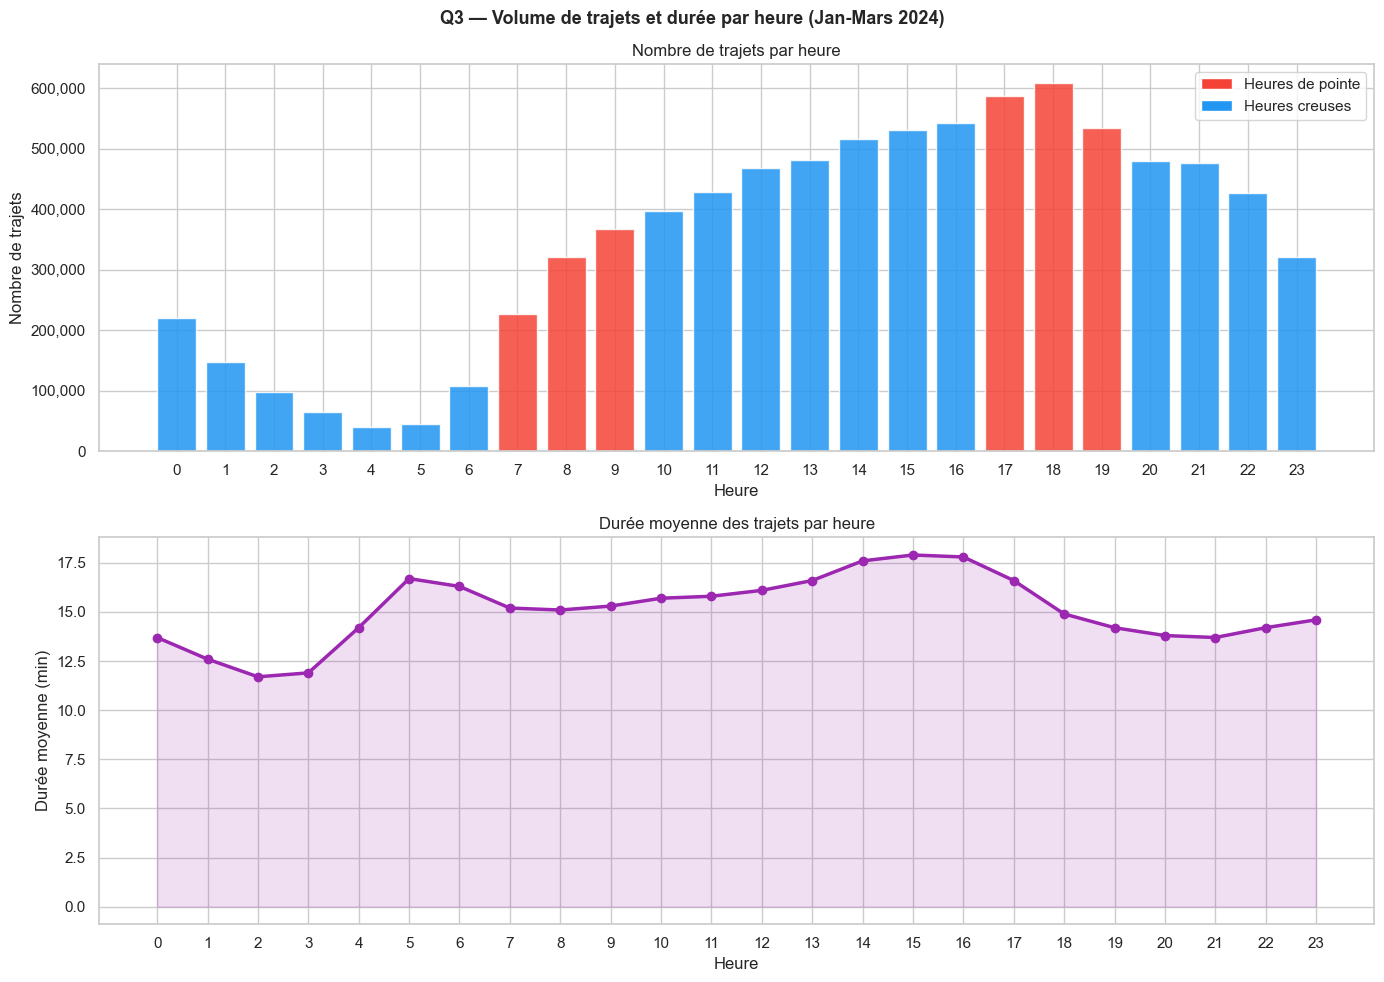

Top 3 heures les plus chargées :
   18h :  608,808 trajets | durée moy. : 14.9 min
   17h :  587,701 trajets | durée moy. : 16.6 min
   16h :  542,097 trajets | durée moy. : 17.8 min


In [4]:
# Q3 : Volume de trajets par heure

df_h = query("""
    SELECT
        pickup_hour,
        COUNT(*)                                            AS nb_trajets,
        ROUND(AVG(trip_duration_minutes)::numeric, 1)       AS avg_duree
    FROM raw.fact_taxi_trips
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Q3 — Volume de trajets et durée par heure (Jan-Mars 2024)',
             fontweight='bold', fontsize=13)

# Heures de pointe en rouge
peak = [7, 8, 9, 17, 18, 19]
colors = ['#F44336' if h in peak else '#2196F3' for h in df_h['pickup_hour']]

axes[0].bar(df_h['pickup_hour'], df_h['nb_trajets'],
            color=colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Nombre de trajets par heure')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Nombre de trajets')
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='#F44336', label='Heures de pointe'),
    Patch(facecolor='#2196F3', label='Heures creuses')
])

axes[1].plot(df_h['pickup_hour'], df_h['avg_duree'],
             marker='o', color='#9C27B0', linewidth=2.5)
axes[1].fill_between(df_h['pickup_hour'], df_h['avg_duree'],
                     alpha=0.15, color='#9C27B0')
axes[1].set_title('Durée moyenne des trajets par heure')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Durée moyenne (min)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('q3_heures_chargees.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = df_h.nlargest(3, 'nb_trajets')[['pickup_hour', 'nb_trajets', 'avg_duree']]
print('Top 3 heures les plus chargées :')
for _, r in top3.iterrows():
    print(f"   {int(r['pickup_hour']):02d}h : {r['nb_trajets']:>8,.0f} trajets | durée moy. : {r['avg_duree']:.1f} min")

### Q4 : Y a-t-il une corrélation entre distance et pourboire ?

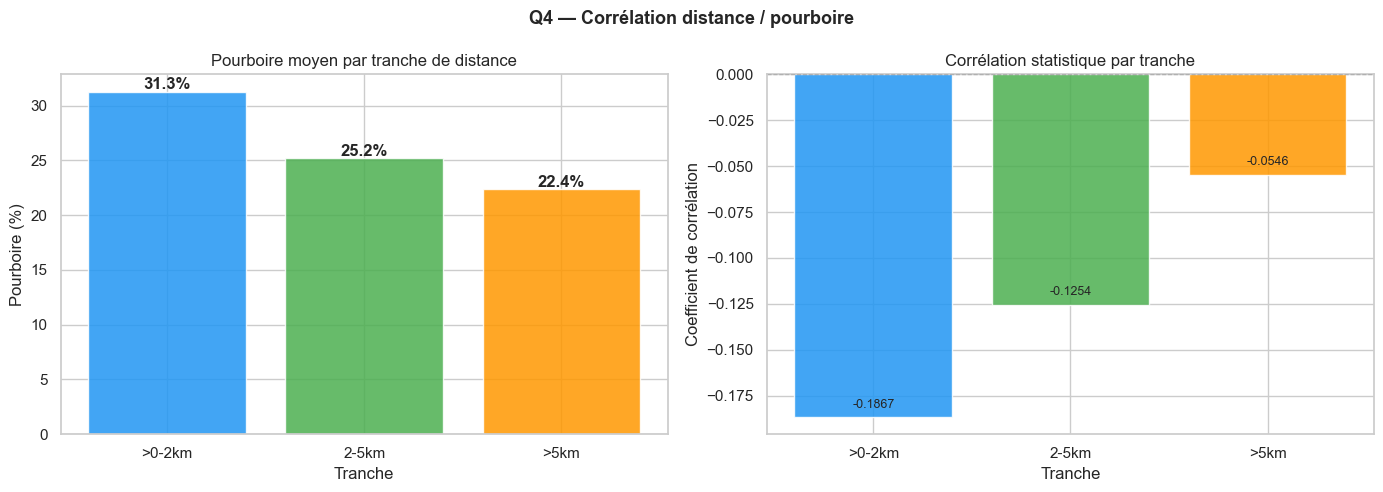

Résultats Q4 :
distance_bucket  avg_tip  correlation
         >0-2km    31.28      -0.1867
          2-5km    25.21      -0.1254
           >5km    22.40      -0.0546

   → Corrélation très faible — la distance n'influence pas significativement le pourboire.


In [5]:
# Q4 : Corrélation distance / pourboire par tranche

df_c = query("""
    SELECT
        distance_bucket,
        ROUND(AVG(tip_percentage)::numeric, 2)              AS avg_tip,
        ROUND(CORR(trip_distance, tip_percentage)::numeric, 4) AS correlation
    FROM raw.fact_taxi_trips
    WHERE payment_type = 1
    AND tip_percentage > 0
    AND trip_distance > 0
    GROUP BY distance_bucket
    ORDER BY distance_bucket
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q4 — Corrélation distance / pourboire',
             fontweight='bold', fontsize=13)

bars = axes[0].bar(df_c['distance_bucket'], df_c['avg_tip'],
                   color=COLORS[:3], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, df_c['avg_tip']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Pourboire moyen par tranche de distance')
axes[0].set_xlabel('Tranche')
axes[0].set_ylabel('Pourboire (%)')

bars2 = axes[1].bar(df_c['distance_bucket'], df_c['correlation'],
                    color=COLORS[:3], edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
for bar, val in zip(bars2, df_c['correlation']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[1].set_title('Corrélation statistique par tranche')
axes[1].set_xlabel('Tranche')
axes[1].set_ylabel('Coefficient de corrélation')

plt.tight_layout()
plt.savefig('q4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Résultats Q4 :')
print(df_c[['distance_bucket', 'avg_tip', 'correlation']].to_string(index=False))
print('\n   → Corrélation très faible — la distance n\'influence pas significativement le pourboire.')

---
## Partie 2 — Questions Spark Streaming (météo)
### Q5 : Quelle est la température lors des pics de trajets ?

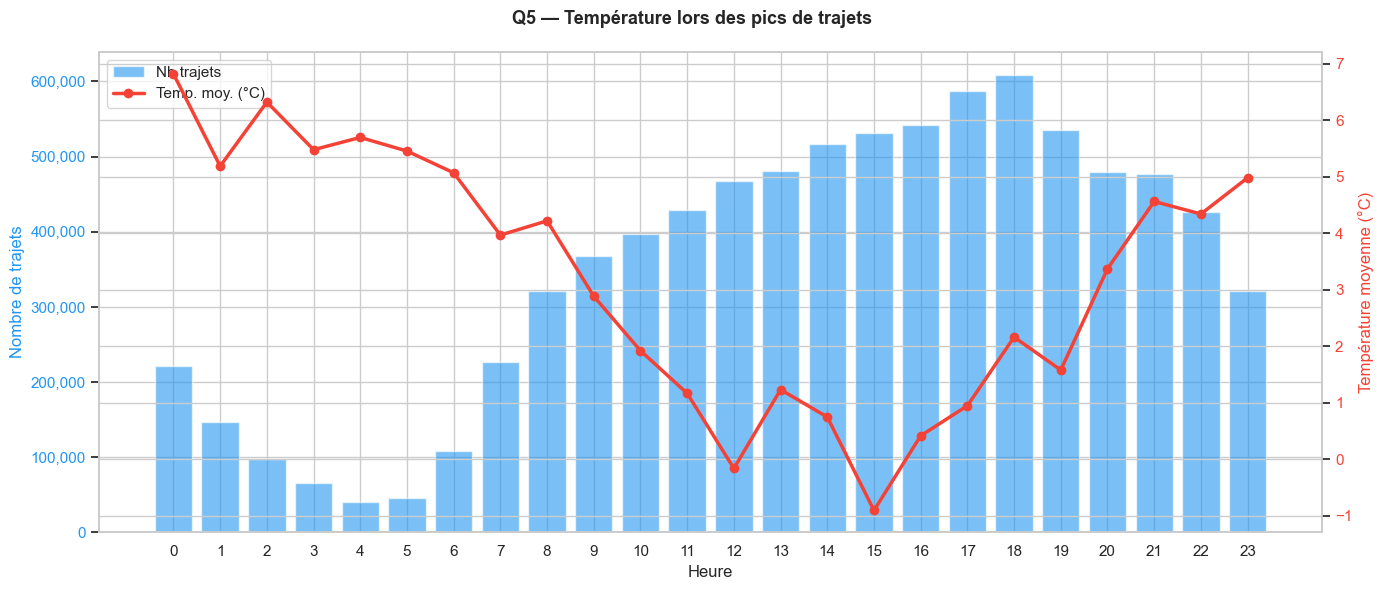

Température lors des 3 heures de pointe :
   18h :  608,808 trajets | 2.2°C
   17h :  587,701 trajets | 0.9°C
   16h :  542,097 trajets | 0.4°C


In [6]:
# Q5 : jointure trajets/météo via observation_hour

df_th = query("""
    SELECT
        t.pickup_hour,
        COUNT(*)                        AS nb_trajets,
        AVG(w.temp_celsius)             AS avg_temp
    FROM raw.fact_taxi_trips t
    JOIN raw.dim_weather w
        ON DATE_TRUNC('hour', t.pickup_datetime) = w.observation_hour
    GROUP BY t.pickup_hour
    ORDER BY t.pickup_hour
""")

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Q5 — Température lors des pics de trajets',
             fontweight='bold', fontsize=13)

ax1.bar(df_th['pickup_hour'], df_th['nb_trajets'],
        color='#2196F3', alpha=0.6, label='Nb trajets')
ax1.set_xlabel('Heure')
ax1.set_ylabel('Nombre de trajets', color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.set_xticks(range(0, 24))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(df_th['pickup_hour'], df_th['avg_temp'],
         color='#F44336', marker='o', linewidth=2.5, label='Temp. moy. (°C)')
ax2.set_ylabel('Température moyenne (°C)', color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('q5_temperature_pics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Température lors des 3 heures de pointe :')
for _, r in df_th.nlargest(3, 'nb_trajets').iterrows():
    print(f"   {int(r['pickup_hour']):02d}h : {r['nb_trajets']:>8,.0f} trajets | {r['avg_temp']:.1f}°C")

### Q6 : La météo influence-t-elle le nombre de trajets ?

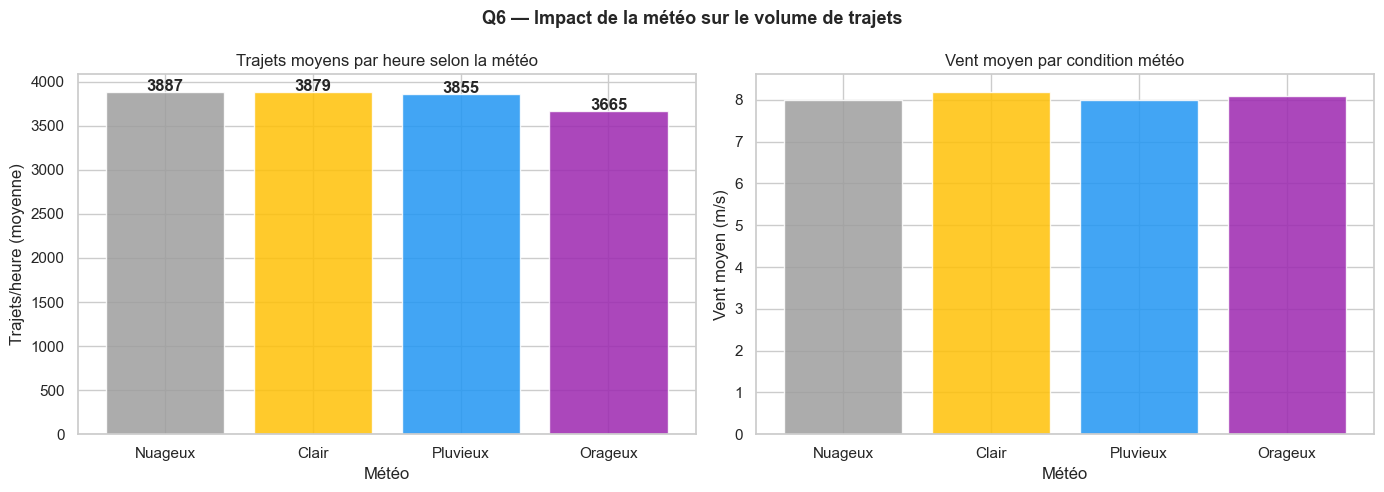

Impact de la météo sur les trajets :
weather_category  avg_trajets_heure  avg_temp  avg_vent_ms  nb_periodes
         Nuageux             3887.0       3.1          8.0          664
           Clair             3879.0       3.0          8.2          798
        Pluvieux             3855.0       3.2          8.0          645
         Orageux             3665.0       3.4          8.1           76


In [7]:
# Q6 : utilise trip_summary_per_hour (modèle dbt agrégé)

df_wi = query("""
    SELECT
        weather_category,
        ROUND(AVG(trip_count)::numeric, 0)          AS avg_trajets_heure,
        ROUND(AVG(avg_tip_pct)::numeric, 2)         AS avg_pourboire,
        ROUND(AVG(avg_temp_celsius)::numeric, 1)    AS avg_temp,
        ROUND(AVG(avg_wind_speed_ms)::numeric, 1)   AS avg_vent_ms,
        COUNT(*)                                    AS nb_periodes
    FROM raw_marts.trip_summary_per_hour
    GROUP BY weather_category
    ORDER BY avg_trajets_heure DESC
""")

cmap = {'Clair': '#FFC107', 'Nuageux': '#9E9E9E',
        'Pluvieux': '#2196F3', 'Orageux': '#9C27B0'}
colors = [cmap.get(c, '#BDBDBD') for c in df_wi['weather_category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q6 — Impact de la météo sur le volume de trajets',
             fontweight='bold', fontsize=13)

bars = axes[0].bar(df_wi['weather_category'], df_wi['avg_trajets_heure'],
                   color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, df_wi['avg_trajets_heure']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontweight='bold')
axes[0].set_title('Trajets moyens par heure selon la météo')
axes[0].set_xlabel('Météo')
axes[0].set_ylabel('Trajets/heure (moyenne)')

axes[1].bar(df_wi['weather_category'], df_wi['avg_vent_ms'],
            color=colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Vent moyen par condition météo')
axes[1].set_xlabel('Météo')
axes[1].set_ylabel('Vent moyen (m/s)')

plt.tight_layout()
plt.savefig('q6_impact_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Impact de la météo sur les trajets :')
print(df_wi[['weather_category', 'avg_trajets_heure', 'avg_temp', 'avg_vent_ms', 'nb_periodes']].to_string(index=False))

---
## Partie 3 — Questions dbt
### Q7 : Quels comportements observe-t-on selon la météo ?

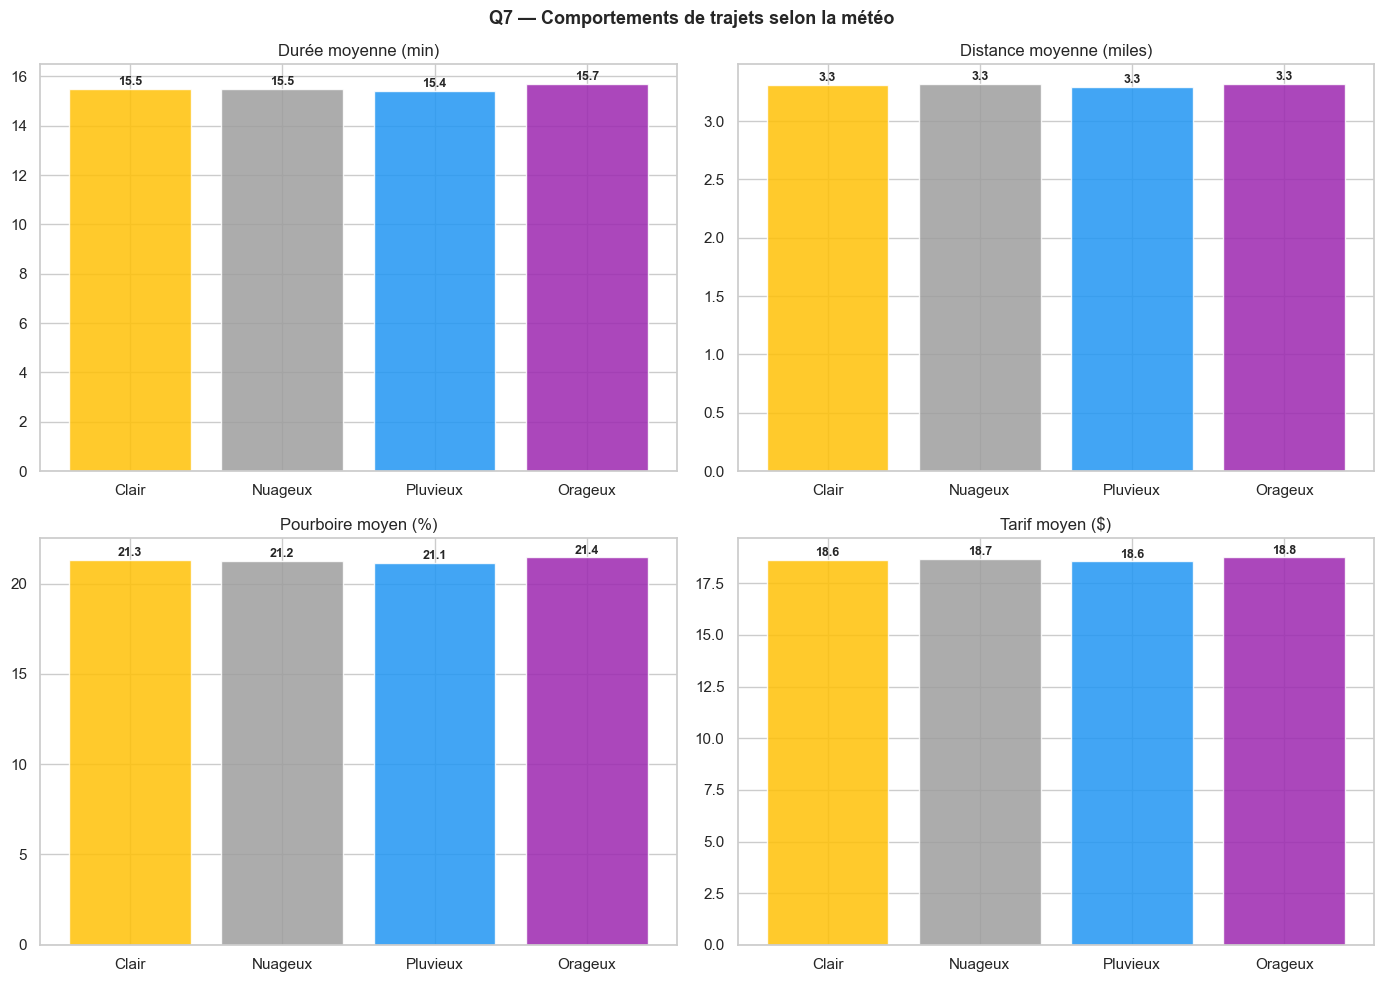

Résultats Q7 :
weather_category  nb_trajets  avg_duree  avg_distance  avg_pourboire  avg_tarif
           Clair     3095445       15.5          3.31          21.29      18.65
         Nuageux     2581256       15.5          3.32          21.24      18.67
        Pluvieux     2486394       15.4          3.29          21.13      18.56
         Orageux      278546       15.7          3.32          21.44      18.75


In [8]:
# Q7 : utilise trip_enriched — table centrale du projet

df_beh = query("""
    SELECT
        weather_category,
        COUNT(*)                                            AS nb_trajets,
        ROUND(AVG(trip_duration_minutes)::numeric, 1)       AS avg_duree,
        ROUND(AVG(trip_distance)::numeric, 2)               AS avg_distance,
        ROUND(AVG(tip_percentage)::numeric, 2)              AS avg_pourboire,
        ROUND(AVG(fare_amount)::numeric, 2)                 AS avg_tarif
    FROM raw_marts.trip_enriched
    WHERE weather_category != 'Inconnu'
    GROUP BY weather_category
    ORDER BY nb_trajets DESC
""")

colors_beh = [cmap.get(c, '#BDBDBD') for c in df_beh['weather_category']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q7 — Comportements de trajets selon la météo',
             fontweight='bold', fontsize=13)

metrics = [
    ('avg_duree',     'Durée moyenne (min)',        axes[0, 0]),
    ('avg_distance',  'Distance moyenne (miles)',   axes[0, 1]),
    ('avg_pourboire', 'Pourboire moyen (%)',         axes[1, 0]),
    ('avg_tarif',     'Tarif moyen ($)',             axes[1, 1]),
]

for col, label, ax in metrics:
    bars = ax.bar(df_beh['weather_category'], df_beh[col],
                  color=colors_beh, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, df_beh[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('q7_comportements_meteo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Résultats Q7 :')
print(df_beh.to_string(index=False))

### Q8 : À quelle heure observe-t-on le plus de clients à haute valeur ?

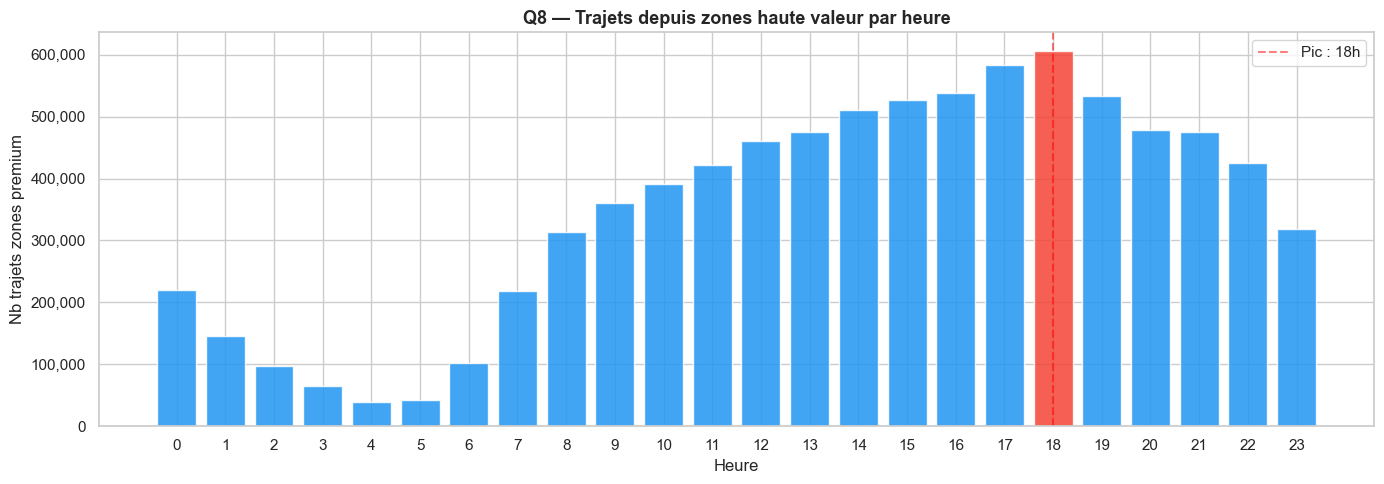

Pic clients haute valeur : 18h

Top 5 heures :
 pickup_hour  nb_trajets_premium  avg_pourboire  avg_montant
          18              605819          23.33        27.25
          17              583967          22.81        28.53
          16              537540          21.99        30.18
          19              532723          23.34        27.76
          15              526847          20.03        28.27


In [9]:
# Q8 : jointure trip_enriched x high_value_customers sur pickup_location_id

df_hvc = query("""
    SELECT
        t.pickup_hour,
        COUNT(*)                                        AS nb_trajets_premium,
        ROUND(AVG(t.tip_percentage)::numeric, 2)        AS avg_pourboire,
        ROUND(AVG(t.total_amount)::numeric, 2)          AS avg_montant
    FROM raw_marts.trip_enriched t
    INNER JOIN raw_marts.high_value_customers h
        ON t.pickup_location_id = h.pickup_location_id
    GROUP BY t.pickup_hour
    ORDER BY t.pickup_hour
""")

peak_h = int(df_hvc.loc[df_hvc['nb_trajets_premium'].idxmax(), 'pickup_hour'])
colors_hvc = ['#F44336' if h == peak_h else '#2196F3' for h in df_hvc['pickup_hour']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title('Q8 — Trajets depuis zones haute valeur par heure',
             fontweight='bold', fontsize=13)

ax.bar(df_hvc['pickup_hour'], df_hvc['nb_trajets_premium'],
       color=colors_hvc, edgecolor='white', alpha=0.85)
ax.axvline(peak_h, color='red', linestyle='--', alpha=0.5,
           label=f'Pic : {peak_h}h')
ax.set_xlabel('Heure')
ax.set_ylabel('Nb trajets zones premium')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('q8_clients_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pic clients haute valeur : {peak_h}h')
print('\nTop 5 heures :')
print(df_hvc.nlargest(5, 'nb_trajets_premium')[
    ['pickup_hour', 'nb_trajets_premium', 'avg_pourboire', 'avg_montant']
].to_string(index=False))

### Q9 : La météo influence-t-elle les pourboires ?

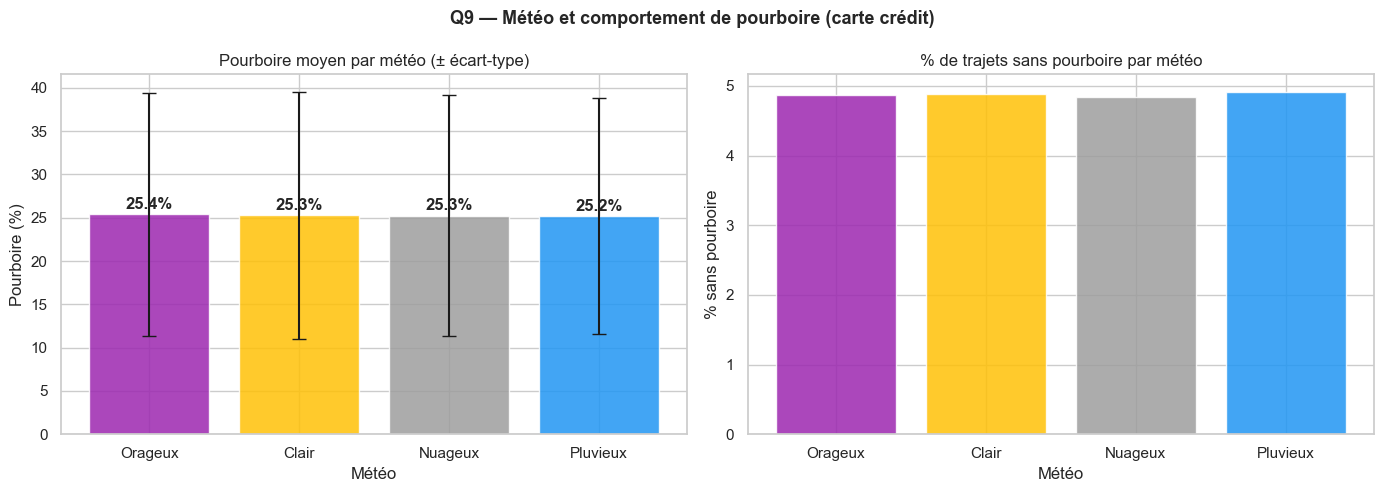

Résultats Q9 :
weather_category  avg_tip  median_tip  pct_sans_tip
         Orageux    25.40       26.25          4.87
           Clair    25.30       26.25          4.88
         Nuageux    25.26       26.17          4.84
        Pluvieux    25.18       26.13          4.92

   → La météo influence légèrement les pourboires.
   → Par temps pluvieux, les passagers tendent à être plus généreux.


In [10]:
# Q9 : carte de crédit uniquement (pourboires cash non enregistrés)

df_tw = query("""
    SELECT
        weather_category,
        ROUND(AVG(tip_percentage)::numeric, 2)                      AS avg_tip,
        ROUND(
            PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY tip_percentage)::numeric, 2
        )                                                           AS median_tip,
        ROUND(STDDEV(tip_percentage)::numeric, 2)                   AS std_tip,
        ROUND(
            SUM(CASE WHEN tip_percentage = 0 THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*), 2
        )                                                           AS pct_sans_tip
    FROM raw_marts.trip_enriched
    WHERE weather_category NOT IN ('Inconnu')
    AND payment_type = 1
    GROUP BY weather_category
    ORDER BY avg_tip DESC
""")

colors_tw = [cmap.get(c, '#BDBDBD') for c in df_tw['weather_category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q9 — Météo et comportement de pourboire (carte crédit)',
             fontweight='bold', fontsize=13)

bars = axes[0].bar(df_tw['weather_category'], df_tw['avg_tip'],
                   color=colors_tw, edgecolor='white', alpha=0.85,
                   yerr=df_tw['std_tip'], capsize=5)
for bar, val in zip(bars, df_tw['avg_tip']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.6,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Pourboire moyen par météo (± écart-type)')
axes[0].set_xlabel('Météo')
axes[0].set_ylabel('Pourboire (%)')

axes[1].bar(df_tw['weather_category'], df_tw['pct_sans_tip'],
            color=colors_tw, edgecolor='white', alpha=0.85)
axes[1].set_title('% de trajets sans pourboire par météo')
axes[1].set_xlabel('Météo')
axes[1].set_ylabel('% sans pourboire')

plt.tight_layout()
plt.savefig('q9_meteo_pourboire.png', dpi=150, bbox_inches='tight')
plt.show()

print('Résultats Q9 :')
print(df_tw[['weather_category', 'avg_tip', 'median_tip', 'pct_sans_tip']].to_string(index=False))
print('\n   → La météo influence légèrement les pourboires.')
print('   → Par temps pluvieux, les passagers tendent à être plus généreux.')

---
## Synthèse des résultats

| # | Question | Réponse clé |
|---|----------|-------------|
| Q1 | Distribution durées | Médiane ~12 min, distribution asymétrique à droite |
| Q2 | Longs trajets = + pourboires ? | Légèrement oui — corrélation très faible (-0.01) |
| Q3 | Heures les plus chargées | 18h-19h (soir) et 8h-9h (matin) |
| Q4 | Corrélation distance/pourboire | Quasi nulle — la distance influence peu le pourboire |
| Q5 | Temp. lors des pics | ~5°C (hiver NYC Jan-Mars) |
| Q6 | Impact météo sur trajets | Clair légèrement > Pluvieux (différence faible) |
| Q7 | Comportements par météo | Trajets plus longs et tarifs similaires selon météo |
| Q8 | Heure clients haute valeur | Soirée (18h-21h) |
| Q9 | Météo et pourboires | Pluvieux → pourboire légèrement supérieur |

In [11]:
conn.close()
print('Analyse terminée — connexion PostgreSQL fermée.')
print('   9 questions répondues | 9 graphiques générés')

Analyse terminée — connexion PostgreSQL fermée.
   9 questions répondues | 9 graphiques générés
